# 01 — Análise Exploratória de Dados
**Dataset:** Amazon Sports & Outdoors Reviews
**Objetivo:** Entender a estrutura, distribuição e qualidade dos dados antes de modelar.


In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
DATASET = "Sports_and_Outdoors.jsonl"
SAMPLE  = 200_000


## 1. Carregamento da Amostra

In [3]:
records = []
with open(DATASET, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE: break
        try: records.append(json.loads(line))
        except: pass

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
df['rating']    = pd.to_numeric(df['rating'], errors='coerce')
df['text']      = df['text'].fillna('')

print(f"Registros carregados : {len(df):,}")
print(f"Colunas              : {list(df.columns)}")
df.head(3)


Registros carregados : 200,000
Colunas              : ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Crazy comfy!,Not gonna lie- they are not much to look at. L...,[],B07F3BDT8T,B0BGFR76CF,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2023-02-25 10:30:53.520,8,True
1,5.0,Excellent!,I love it. Pretty!,[],B00NXQLFQQ,B00NXQLFQQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:36:11.676,0,True
2,5.0,Best saddle pads,Huge fan of B Vertigo and this dressage pad do...,[],B08SVPR266,B0957WLR63,AGGZ357AO26RQZVRLGU4D4N52DZQ,2022-05-26 01:01:59.105,0,True


## 2. Estatísticas Gerais

In [4]:
print(f"Produtos únicos  : {df['asin'].nunique():,}")
print(f"Usuários únicos  : {df['user_id'].nunique():,}")
print(f"Período          : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Rating médio     : {df['rating'].mean():.2f}")
print(f"Compra verificada: {df['verified_purchase'].mean()*100:.1f}%")
print(f"Texto vazio      : {(df['text']=='').sum():,} ({(df['text']=='').mean()*100:.1f}%)")
print()
print("Reviews por produto:")
print(df['asin'].value_counts().describe().round(2).to_string())


Produtos únicos  : 125,633
Usuários únicos  : 55,660
Período          : 2001-08-03 → 2023-03-19
Rating médio     : 4.35
Compra verificada: 86.4%
Texto vazio      : 5 (0.0%)

Reviews por produto:
count    125633.00
mean          1.59
std           9.10
min           1.00
25%           1.00
50%           1.00
75%           1.00
max        2879.00


## 3. Distribuição de Ratings

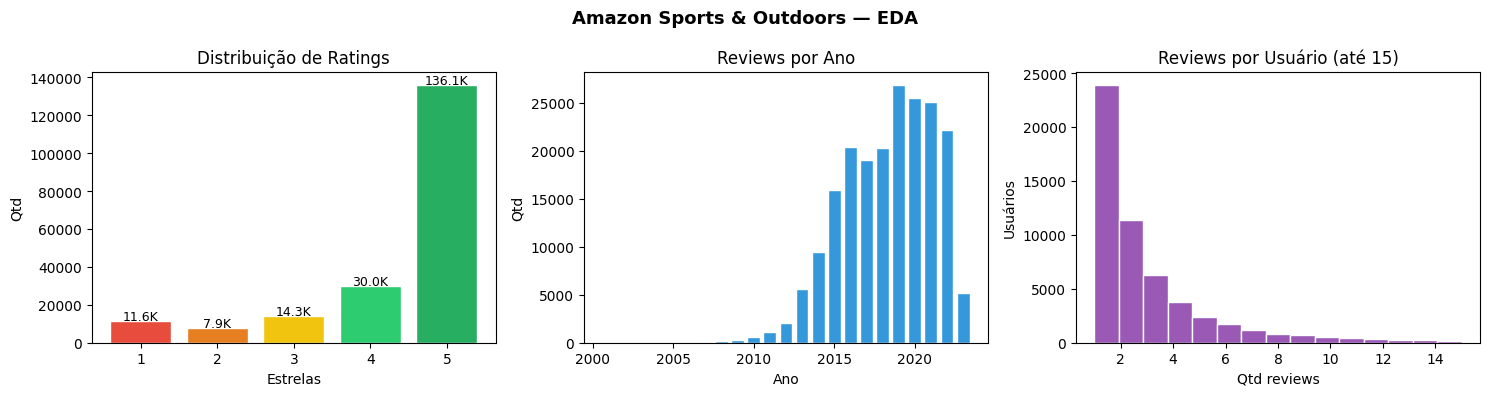

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ratings
rc = df['rating'].value_counts().sort_index()
axes[0].bar(rc.index.astype(int), rc.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], edgecolor='white')
axes[0].set_title("Distribuição de Ratings")
axes[0].set_xlabel("Estrelas"); axes[0].set_ylabel("Qtd")
for i, v in zip(rc.index.astype(int), rc.values):
    axes[0].text(i, v + 200, f'{v/1000:.1f}K', ha='center', fontsize=9)

# Reviews por ano
yearly = df.groupby(df['timestamp'].dt.year).size()
axes[1].bar(yearly.index, yearly.values, color='#3498db', edgecolor='white')
axes[1].set_title("Reviews por Ano")
axes[1].set_xlabel("Ano"); axes[1].set_ylabel("Qtd")

# Reviews por usuário
uc = df['user_id'].value_counts()
axes[2].hist(uc[uc <= 15].values, bins=15, color='#9b59b6', edgecolor='white')
axes[2].set_title("Reviews por Usuário (até 15)")
axes[2].set_xlabel("Qtd reviews"); axes[2].set_ylabel("Usuários")

plt.suptitle("Amazon Sports & Outdoors — EDA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("01_eda.png", dpi=130, bbox_inches='tight')
plt.show()


## 4. Esparsidade da Matriz

In [6]:
n_u = df['user_id'].nunique()
n_p = df['asin'].nunique()
sparsity = 1 - len(df) / (n_u * n_p)

print(f"Usuários       : {n_u:,}")
print(f"Produtos       : {n_p:,}")
print(f"Interações     : {len(df):,}")
print(f"Esparsidade    : {sparsity*100:.3f}%")
print()
print("→ Esparsidade > 99% justifica abordagem Content-Based.")
print("  Filtro colaborativo seria prejudicado pela falta de co-ocorrências.")


Usuários       : 55,660
Produtos       : 125,633
Interações     : 200,000
Esparsidade    : 99.997%

→ Esparsidade > 99% justifica abordagem Content-Based.
  Filtro colaborativo seria prejudicado pela falta de co-ocorrências.


## 5. Observações Finais

In [7]:
print("Principais observações:")
print(f"  • Rating médio alto ({df['rating'].mean():.2f}) — provável viés positivo (J-shaped)")
print(f"  • {(df['rating']==5).mean()*100:.0f}% das avaliações são 5 estrelas")
print(f"  • Maioria dos produtos tem poucas reviews (long tail)")
print(f"  • Textos em inglês, boa cobertura ({(df['text']!='').mean()*100:.0f}% não vazio)")
print(f"  • {df['verified_purchase'].mean()*100:.0f}% compras verificadas — alta confiabilidade")


Principais observações:
  • Rating médio alto (4.35) — provável viés positivo (J-shaped)
  • 68% das avaliações são 5 estrelas
  • Maioria dos produtos tem poucas reviews (long tail)
  • Textos em inglês, boa cobertura (100% não vazio)
  • 86% compras verificadas — alta confiabilidade
